# A Notebook for Kriging Tests with White Gaussian Noise sim data

In [2]:
import numpy as np
import statistics as stat
import scipy
from matplotlib import pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
# import PrizmCalibration as cl # this module is missing dependencies
# from gsm_data import GSMData, get_desired_frequencies
# from data_prep import DataPrep

# # For reloading the module (useful for debugging)
# import data
# import data_prep
# try:
#     reload(data) # dependent module (imported in data_prep)
#     reload(data_prep)
#     from data_prep import DataPrep
# except:
#     from importlib import reload
#     reload(data) # dependent module (imported in data_prep)
#     reload(data_prep)
#     from data_prep import DataPrep

from helper_functions import *
import data_utils as du

from importlib import reload
import copy

try:
    reload(test_short_interp)
    from test_short_interp import make_acf
except:
    import test_short_interp
    reload(test_short_interp)
    from test_short_interp import make_acf

## Step 0: Load in data

In [2]:
# Flag the 'bad' spectra
# For a first pass I have to fetch the mask from DataPrep
year = '2021'
instrument = '100MHz'
channel = 'NS'

dataprep = DataPrep(instrument, channel, year)
save_mask = copy.deepcopy(dataprep.calib_mask_dict['short']) # save the mask

TypeError: object of type 'NoneType' has no len()

In [46]:
# Actually save the mask so I don't have to load it in every time anymore.
np.save(datadir+'shortdata_2021_100MHz_NS_mask.npy',save_mask)

In [3]:
datadir = '../test_data/2021/100MHz/NS/'

save_mask = np.load(datadir+'shortdata_2021_100MHz_NS_mask.npy')
dat=np.load(datadir+'shortdata_meas_2021_100MHz_NS.npy')[save_mask]
lst=np.load(datadir+'shortlst_2021_100MHz_NS.npy')[save_mask]
t=np.load(datadir+'shortsystime_2021_100MHz_NS.npy')[save_mask]

# dat_nomask = np.load(datadir+'shortdata_meas_2021_100MHz_NS.npy')
# lst_nomask = np.load(datadir+'shortlst_2021_100MHz_NS.npy')
# t_nomask = np.load(datadir+'shortsystime_2021_100MHz_NS.npy')

In [4]:
freqarr, freqstep = np.linspace(0,250,4096,retstep=True) # Based on number of frequency channels of the antenna
minfreq = 30
maxfreq = 200
minfreqarg = int(minfreq/freqstep)
maxfreqarg = int(maxfreq/freqstep)

In [5]:
# vs UNIX timestamp

freq = 100 # MHz
freq_index = int(freq/freqstep)

plt.figure(figsize=(20,5))
# plt.plot(t,dat[:,freq_index],'.',label='All times')
plt.plot(t_gauss,dd_gauss,'.',label='Selected section')
plt.axvline(x=1.6371e9,label='Interp Time (Testing)',color='orange') 
plt.xlabel('UNIX Timestamp [s]')
plt.ylabel('Power [ADC units]')
plt.title('Short, freq_index='+str(freq_index)+', freq='+str(freq)+' MHz')
plt.legend(loc='upper left',bbox_to_anchor=(1, 1))
plt.subplots_adjust(right=0.7)
plt.show()

NameError: name 't_gauss' is not defined

<Figure size 2000x500 with 0 Axes>

In [7]:
print(np.diff(t_nomask))
tmax=np.inf
tmin=0
freq = 100 # MHz
freq_index = int(freq/freqstep)
mask=(t_nomask>tmin)&(t_nomask<tmax)
plt.figure(figsize=(20,5))
plt.plot((t_nomask[mask]-t_nomask[mask][0])/3600,dat_nomask[mask,:][:,freq_index],'.',label='Selected section',zorder=0)

NameError: name 't_nomask' is not defined

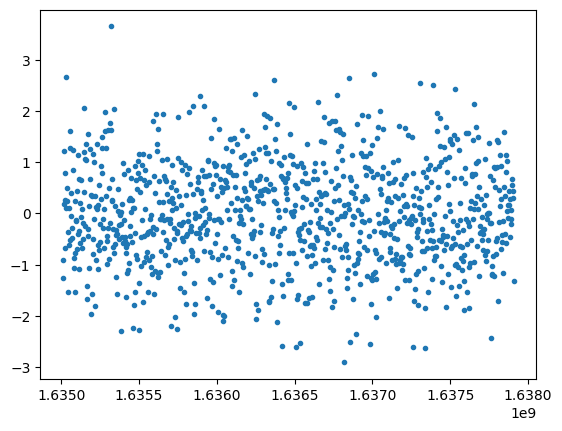

In [9]:
# White Gaussian Noise simulated data -- for testing purposes
tmax=np.inf
tmin=0

mask=(t>tmin)&(t<tmax)
tt=t[mask]
dd=dat[mask,:]
ll=lst[mask]

twgn = np.linspace(np.min(tt),np.max(tt),1000)
wgn_data = np.random.normal(loc=0,scale=1,size=len(twgn))

plt.plot(twgn,wgn_data,'.',label='WGN data')
plt.show()

## Step 1: Compute the autocorrelation function (ACF)

For now (testing purposes) we restrict to:

- one frequency channel: 100 MHz

- one section of the time series

- one data point to interpolate

-0.24580357112832268


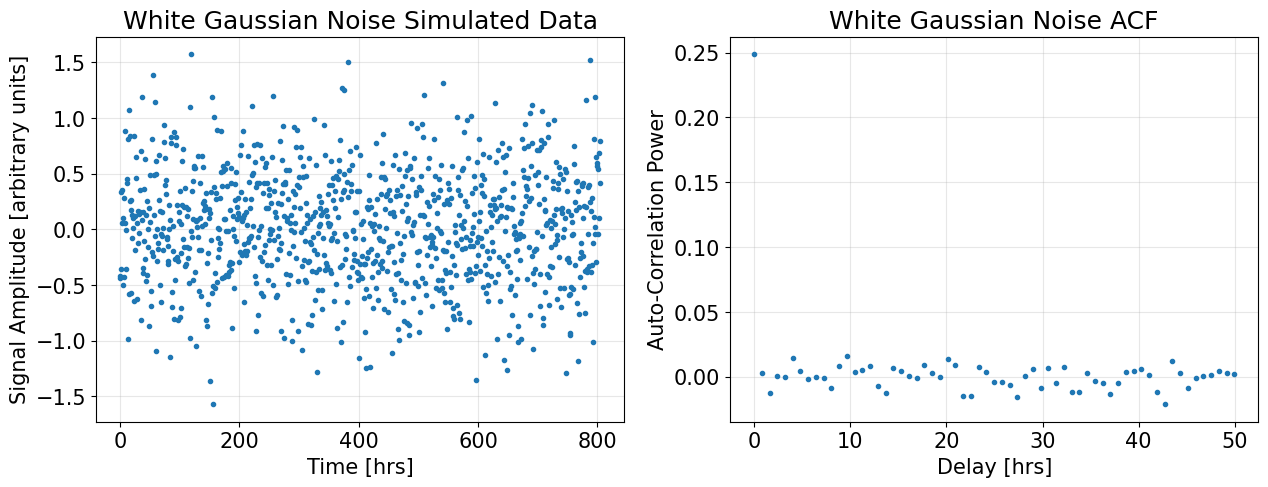

In [101]:
tmax=np.inf
tmin=0

mask=(t>tmin)&(t<tmax)
tt=t[mask]
dd=dat[mask,:]
ll=lst[mask]

plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(1,2,figsize=(15,5))

'''FOR TESTING -- remove and reset later'''
t_gauss, dt = np.linspace(tt[0],tt[-1],1000,retstep=True)
# dd_gauss = np.random.normal(loc=0,scale=0.5,size=len(t_gauss)) + 1*np.sin(2*np.pi/(20*3600) *t_gauss)
dd_gauss = np.random.normal(loc=0,scale=0.5,size=len(t_gauss))
ax[0].plot((t_gauss-t_gauss[0])/3600,dd_gauss,'.',label='WGN data')
ax[0].set_title('White Gaussian Noise Simulated Data')
# ax[0].set_title('Sine+WGN Simulated Data')
ax[0].set_xlabel('Time [hrs]')
ax[0].set_ylabel('Signal Amplitude [arbitrary units]')
ax[0].grid(alpha=0.3)
# ax[0].set_xlim(left=0,right=200)
 # + np.sin(2*np.pi/1.5e5 *t_gauss)
'''--------------------------------------'''

dt= 5 # seconds

# tot,wt=make_acf(dd_gauss[:,freq_index]-dd_gauss[:,freq_index].mean(),t,dt=dt,tmax=2*86400)
tot,wt=make_acf(dd_gauss-dd_gauss.mean(),t_gauss,dt=dt,tmax=2.1*86400)
# tot2,wt2=make_acf_alt(dd[:,freq_index]-dd[:,freq_index].mean(),tt,dt=dt,tmax=2*86400)
# tot,wt=make_acf(dd-dd.mean(),tt,dt=dt,tmax=2*86400)
tvec=np.arange(len(tot))*dt
# tvec2=np.arange(len(tot2))*dt
mm=wt>0
# mm2=wt2>30

ax[1].plot(tvec[mm]/3600,(tot[mm]/wt[mm]),'.')
print((tot[mm]/wt[mm])[1]-(tot[mm]/wt[mm])[0])

# plt.title('Time-correlation, freq_index='+str(freq_index)+', freq='+str(freq)+' MHz\n dt='+str(dt)+'s')
ax[1].set_title('White Gaussian Noise ACF')
# ax[1].set_title('Sine+WGN ACF')
ax[1].set_ylabel('Auto-Correlation Power')
ax[1].set_xlabel('Delay [hrs]')
# ax[1].vlines(x=0,ymin=-2,ymax=2,alpha=0.2,label=r'$\tau=0$ bin')
# ax[1].hlines(y=0.25,xmin=-2,xmax=100,alpha=0.4,ls='--',label='')
# ax[1].set_ylim(-0.2,1.1)
# ax[1].set_xlim(-1,51)
ax[1].grid(alpha=0.3)
# ax[1].legend()
# plt.savefig('WGN-ACF-test-sig05.jpg',dpi=300,bbox_inches='tight')
plt.show()

Since the autocorrelation function still looks a little weird, we will only focus use the dt = 0 to dt = 8h section.

# Step 2: Fit the autocorrelation function

In [263]:
# As a simple first pass for just the 0 to 8h section of the ACF we 
def linfunc(x,a,b):
    return a*x+b

def expfunc(x,a,b):
    return a*np.exp(-x/b)

def quad(x,a,b,c):
    return a*x**2 + b*x + c

def trigfunc(x,a,b,c):
    return a*np.sin(b*x+c)

# def expabsfunc(x,a,b):
#     return a*np.exp(-b*abs(x))

def ACF_fit(a,b,c=np.nan,functype='linear'):
    if functype == 'linear':
        return lambda dt: a*dt+b
    elif functype == 'exponential':
        return lambda dt: a*np.exp(-dt/b)
    elif functype == 'quad':
        return lambda dt: a*dt**2 + b*dt + c
    elif functype == 'trig':
        return lambda dt: a*np.sin(b*dt+c)

def ACF_wgn(dt):
    if dt == 0: return np.random.normal(loc=1,scale=0.03,size=1)
    else: return np.random.normal(loc=0,scale=0.03,size=1)

[0.43303449 0.15189551 1.5224142 ]


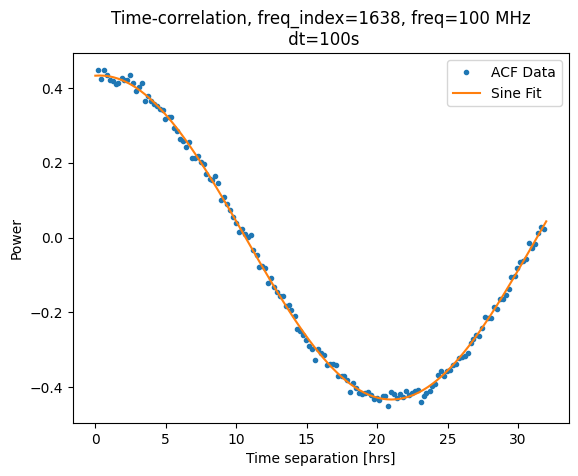

In [264]:
dtmax = 32*3600 # seconds

plt.plot(tvec[mm][tvec[mm]<dtmax]/3600,(tot[mm]/wt[mm])[tvec[mm]<dtmax],'.',label='ACF Data')
tfitvec = np.linspace(0,dtmax/3600,100)

# Do the fit:
# popt, pcov = scipy.optimize.curve_fit(f=linfunc,xdata=tvec[mm][tvec[mm]<dtmax]/3600,ydata=(tot[mm]/wt[mm])[tvec[mm]<dtmax],p0=[-6e10/8,9.1e10])
# plt.plot(tfitvec,linfunc(tfitvec,popt[0],popt[1]),label='Linear Fit')
# popt, pcov = scipy.optimize.curve_fit(f=expfunc,xdata=tvec[mm][tvec[mm]<dtmax]/3600,ydata=(tot[mm]/wt[mm])[tvec[mm]<dtmax],p0=[9.1e10,4])
# plt.plot(tfitvec,expfunc(tfitvec,popt[0],popt[1]),label='Exp Fit')
# popt, pcov = scipy.optimize.curve_fit(f=expabsfunc,xdata=tvec[mm][tvec[mm]<dtmax]/3600,ydata=(tot[mm]/wt[mm])[tvec[mm]<dtmax],p0=[9.1e10,4])
# plt.plot(tfitvec,expabsfunc(tfitvec,popt[0],popt[1]),label='Exp Fit')
popt, pcov = scipy.optimize.curve_fit(f=trigfunc,xdata=tvec[mm][tvec[mm]<dtmax]/3600,ydata=(tot[mm]/wt[mm])[tvec[mm]<dtmax],p0=[0.5,np.pi/15,1])
plt.plot(tfitvec,trigfunc(tfitvec,popt[0],popt[1],popt[2]),label='Sine Fit')


print(popt)

plt.ylabel('Power')
plt.xlabel('Time separation [hrs]')
plt.title('Time-correlation, freq_index='+str(freq_index)+', freq='+str(freq)+' MHz\n dt='+str(dt)+'s')
plt.legend()
plt.show()


# ACF_func = ACF_fit(popt[0],popt[1],functype='linear')
# ACF_func = ACF_fit(popt[0],popt[1],popt[2],functype='trig')

## Step 3: Build the covariance matrix

In [265]:
# "d": the data array, for convenience we put the point where we want to interpolate (marked by a 0) at the end 
# of the array of existing data

interp_time = 1.637e9 # seconds

# "C": the covariance matrix of data d
'''Making a matrix with only the data within 8h of the interp time'''
# I had to reduce to 8h total (4h around interp time) interval so there's no need to use the ACF at dt > 8h
d_red = dd_gauss[abs(t_gauss - interp_time) < 8/2*3600] 
t_red = t_gauss[abs(t_gauss - interp_time) < 8/2*3600]
d = np.append(d_red,0)
tarr = np.append(t_red,interp_time)
C = np.zeros(shape=(len(d),len(d))) # initialize
'''--------------------------------------'''
# d = np.append(dd_gauss,0) # append 0 to end of data array
# d = np.append(dd,0)
# tarr = np.append(t_gauss,interp_time) # append the time where we want to generate an interpolated point
# C = np.zeros(shape=(len(d),len(d))) # initialize

for i in range(len(d)):
    for j in range(len(d)):
        dtij = abs(tarr[i]-tarr[j]) # time separation between points
        
        if dtij > 8*3600:
            # For now, we are only using the ACF up to dt = 8 hours. If dtij > 8h, set C_ij = 0 (uncorrelated).
            print('larger')
            print(dtij)
            C[i,j] = 0
        else:
            C[i,j] = ACF_func(dt=dtij/3600) # ACF_func is defined for dt in hours

## Step 4: Invert the covariance matrix

In [266]:
Cinv = np.linalg.inv(C)

# U, Sdiag, VT = np.linalg.svd(C, full_matrices=False) # SVD
# Cinv_svd = VT.T @ np.diag(1/Sdiag) @ U.T

# lam, Q = scipy.linalg.eig(C) # eigenvector/value
# lam = np.real(lam)
# Q = np.real(Q)
# print(lam)
# Cinv_eig = Q @ np.diag(1/lam) @ np.linalg.inv(Q)

# print(Cinv_svd.shape)
# print(Cinv.shape)
# print(Cinv_eig.shape)
# print(np.sum(abs(Cinv-Cinv_svd)))
# print(np.sum(abs(Cinv-Cinv_eig)))

## Step 5: Compute the weights for each data point

The interpolated value consists of a weighted sum of existing data, where the weights are given by:

$$ w[1..n]= \frac{-C^{-1}[n+1,1..n]}{C^{-1}[n+1][n+1]} $$

where $n$ is the number of measured data points, and $n+1$ is due to adding the new interpolated point to the end of the data array.

In [267]:
# "w": array of weights for the weighted sum to compute inteprolated value
n = len(d)-1
w = -Cinv[n,0:n] / Cinv[n,n]

## Step 6: Compute the weighted sum

In [268]:
dinterp = np.dot(w,d[0:n])
dinterp

0.7630306358835303

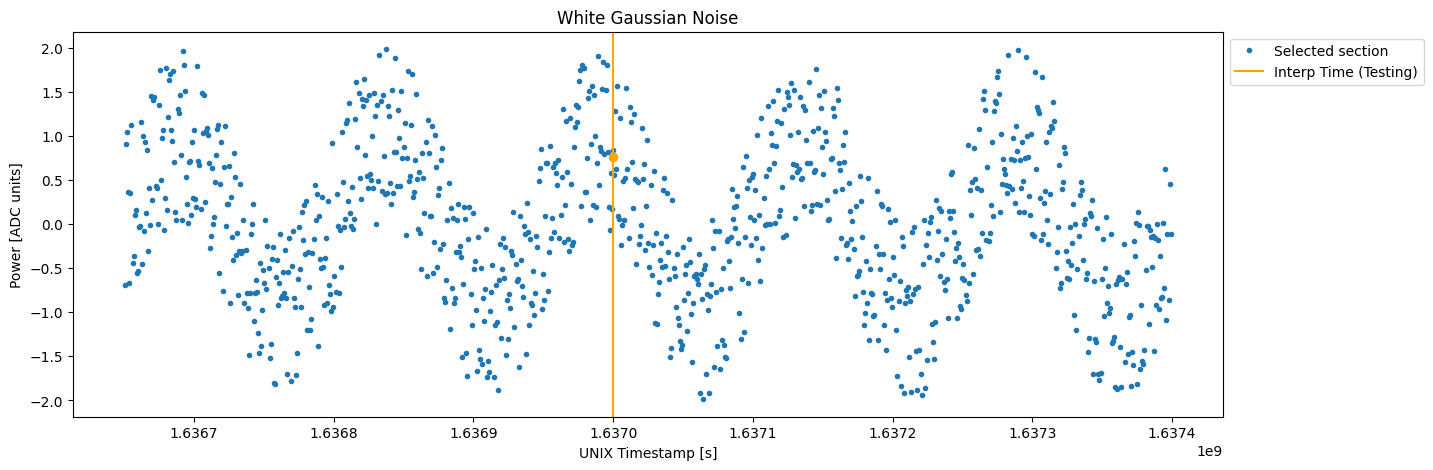

In [269]:
# Let's plot the result

plt.figure(figsize=(20,5))
# plt.plot(t,dat[:,freq_index],'.',label='All times')
plt.plot(t_gauss,dd_gauss,'.',label='Selected section',zorder=0)
# plt.plot(tt,dd,'.',label='WGN')
plt.axvline(x=interp_time,label='Interp Time (Testing)',color='orange',zorder=1) 
plt.scatter(interp_time,dinterp,color='orange')
plt.xlabel('UNIX Timestamp [s]')
plt.ylabel('Power [ADC units]')
# plt.title('Short, freq_index='+str(freq_index)+', freq='+str(freq)+' MHz')
plt.title('White Gaussian Noise')
plt.legend(loc='upper left',bbox_to_anchor=(1, 1))
plt.subplots_adjust(right=0.7)
plt.show()

Hmmmm ok this does not look good.
Try plotting the weights to make sure it works?
Maybe the problem is with the proper inversion of the C matrix. Look into matrix decomposition tricks from phys 512.

ValueError: x and y must be the same size

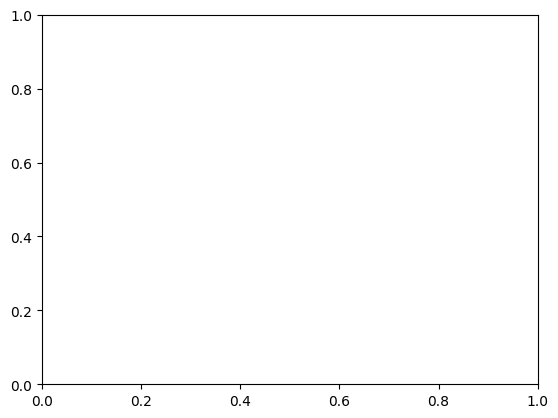

In [89]:
# plt.scatter(tt[abs(w)<100],w[abs(w)<100])
plt.scatter(tt,w)
plt.axvline(x=interp_time,label='Interp Time (Testing)',color='orange') 
plt.show()

# why does this look like zero sometimes  and random other times????
tt[w>200]